<h1 style="text-align:center;"><b>Multi-Output Time Series Forecasting (LSTM)</b></h1>

<b>Name:</b> DANIYA SHAMEEM<br>
<b>Student ID:</b> 202511024<br>
<b>Roll Number:</b> 08<br>
<b>Dataset Used:</b> BPCL.csv<br>

The following approach was implemented in this assignment:
- Acquiring and loading of the NIFTY-50 stock market dataset (BPCL data)
- Data preprocessing and cleaning  
- Feature selection and scaling  
- Sequence generation for time-series modeling  
- LSTM model training  
- Performance evaluation using MSE, MAE, and RMSE  
- Visualization of results using actual vs predicted plots  

<b>1. LOADING THE DATASET</b>

In [1]:
import pandas as pd
import numpy as np

In [5]:
df = pd.read_csv("BPCL.csv")
df.head()

,Date,Symbol,Series,Prev Close,Open,High,Low,Last,Close,VWAP,Volume,Turnover,Trades,Deliverable Volume,%Deliverble
0,2000-01-03,BPCL,EQ,381.20,405.00,407.00,393.05,397.75,399.25,399.32,8720,3.482029e+11,NaN,NaN,NaN
1,2000-01-04,BPCL,EQ,399.25,397.75,397.75,367.40,377.45,370.50,375.71,22820,8.573699e+11,NaN,NaN,NaN
2,2000-01-05,BPCL,EQ,370.50,350.00,385.00,350.00,360.10,359.95,359.96,152538,5.490785e+12,NaN,NaN,NaN
3,2000-01-06,BPCL,EQ,359.95,362.00,384.00,362.00,381.65,380.30,380.10,59554,2.263623e+12,NaN,NaN,NaN
4,2000-01-07,BPCL,EQ,380.30,369.00,390.00,366.00,381.50,379.85,378.33,43187,1.633890e+12,NaN,NaN,NaN


<b>2. DATA PREPROCESSING</b> (Cleaning and Normalizing)

In [6]:
df['Date'] = pd.to_datetime(df['Date'])
df = df.sort_values('Date').reset_index(drop=True)


In [36]:
print(df.isnull().sum())

Date                  0
Symbol                0
Series                0
Prev Close            0
Open                  0
High                  0
Low                   0
Last                  0
Close                 0
VWAP                  0
Volume                0
Turnover              0
Trades                0
Deliverable Volume    0
%Deliverble           0
dtype: int64


In [7]:
df = df.ffill().bfill()

In [ ]:
dates = df['Date'].copy()

# Dropping non-numerical features
data = df.drop(columns=['Date', 'Symbol', 'Series', 'Trades']) 

<b>Feature Scaling</b>

In [11]:
from sklearn.preprocessing import MinMaxScaler

In [12]:
scaler = MinMaxScaler()
scaled_data = scaler.fit_transform(data)

In [13]:
print("Any NaN in scaled_data:", np.isnan(scaled_data).any())
print("Any Inf in scaled_data:", np.isinf(scaled_data).any())

Any NaN in scaled_data: False
Any Inf in scaled_data: False


<b>3. CREATING SEQUENCES</b>

In [14]:
def create_sequences(data, input_window=10, output_window=5):
    X, y = [], []

    for i in range(len(data) - input_window - output_window):
        X.append(data[i:i+input_window])
        y.append(data[i+input_window:i+input_window+output_window])

    return np.array(X), np.array(y)


X, y = create_sequences(scaled_data)

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (5291, 10, 11)
y shape: (5291, 5, 11)


Aligning Dates with Sequence

In [15]:
input_window = 10

dates = dates[input_window:]
dates = dates[:len(X)]

Converting to Tensor

In [16]:
import torch
import torch.nn as nn

In [17]:
X_tensor = torch.tensor(X, dtype=torch.float32)
y_tensor = torch.tensor(y, dtype=torch.float32)

<b>4. BUILDING THE MODEL</b>

In [18]:
class LSTMModel(nn.Module):
    def __init__(self, input_size, hidden_size, output_size):
        super(LSTMModel, self).__init__()
        
        self.lstm = nn.LSTM(input_size, hidden_size, batch_first=True)
        self.fc = nn.Linear(hidden_size, output_size)

    def forward(self, x):
        out, _ = self.lstm(x)
        out = out[:, -1, :]
        out = self.fc(out)
        return out

In [19]:
input_size = X.shape[2]
hidden_size = 64
output_size = y.shape[1] * y.shape[2]

model = LSTMModel(input_size, hidden_size, output_size)

criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

<b>Training Loop<b>

In [20]:
epochs = 50

for epoch in range(epochs):
    model.train()

    outputs = model(X_tensor)

    y_reshaped = y_tensor.view(y_tensor.size(0), -1)

    loss = criterion(outputs, y_reshaped)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    print(f"Epoch {epoch+1}/{epochs}, Loss: {loss.item():.4f}")

Epoch 1/50, Loss: 0.1122
Epoch 2/50, Loss: 0.1086
Epoch 3/50, Loss: 0.1052
Epoch 4/50, Loss: 0.1018
Epoch 5/50, Loss: 0.0983
Epoch 6/50, Loss: 0.0948
Epoch 7/50, Loss: 0.0912
Epoch 8/50, Loss: 0.0874
Epoch 9/50, Loss: 0.0834
Epoch 10/50, Loss: 0.0791
Epoch 11/50, Loss: 0.0746
Epoch 12/50, Loss: 0.0697
Epoch 13/50, Loss: 0.0645
Epoch 14/50, Loss: 0.0590
Epoch 15/50, Loss: 0.0531
Epoch 16/50, Loss: 0.0471
Epoch 17/50, Loss: 0.0410
Epoch 18/50, Loss: 0.0353
Epoch 19/50, Loss: 0.0305
Epoch 20/50, Loss: 0.0271
Epoch 21/50, Loss: 0.0256
Epoch 22/50, Loss: 0.0251
Epoch 23/50, Loss: 0.0243
Epoch 24/50, Loss: 0.0224
Epoch 25/50, Loss: 0.0197
Epoch 26/50, Loss: 0.0169
Epoch 27/50, Loss: 0.0145
Epoch 28/50, Loss: 0.0128
Epoch 29/50, Loss: 0.0118
Epoch 30/50, Loss: 0.0113
Epoch 31/50, Loss: 0.0111
Epoch 32/50, Loss: 0.0110
Epoch 33/50, Loss: 0.0108
Epoch 34/50, Loss: 0.0105
Epoch 35/50, Loss: 0.0101
Epoch 36/50, Loss: 0.0097
Epoch 37/50, Loss: 0.0092
Epoch 38/50, Loss: 0.0088
Epoch 39/50, Loss: 0.

Loss is decreasing steadily.

<b>5. PREDICTIONS</b>

In [26]:
model.eval()

with torch.no_grad():
    pred = model(X_tensor)

pred_np = pred
y_np = y_tensor.view(y_tensor.size(0), -1)

pred_np = pred_np.reshape(pred_np.shape[0], 5, -1)
y_np = y_np.reshape(y_np.shape[0], 5, -1)


<b>6. EVALUATING THE MODEL </b> (Using Evalaution Metrics)

In [27]:
from sklearn.metrics import mean_squared_error, mean_absolute_error
import numpy as np

mse = mean_squared_error(y_np.reshape(-1), pred_np.reshape(-1)) # Reshaping to flatten 3D to 1D array
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_np.reshape(-1), pred_np.reshape(-1))

print("MSE:", mse)
print("RMSE:", rmse)
print("MAE:", mae)

MSE: 0.005980388261377811
RMSE: 0.0773329700798942
MAE: 0.049009211361408234


<b>7. PLOTTING THE GRAPH</b> (Date-wise predictions and true known values on the same dates)

In [28]:
close_index = list(data.columns).index('Close')


In [30]:
actual = y[:, 0, close_index]
predicted = pred_np[:, 0, close_index]

In [31]:
dates_plot = dates[:len(actual)]

In [33]:
import matplotlib.pyplot as plt

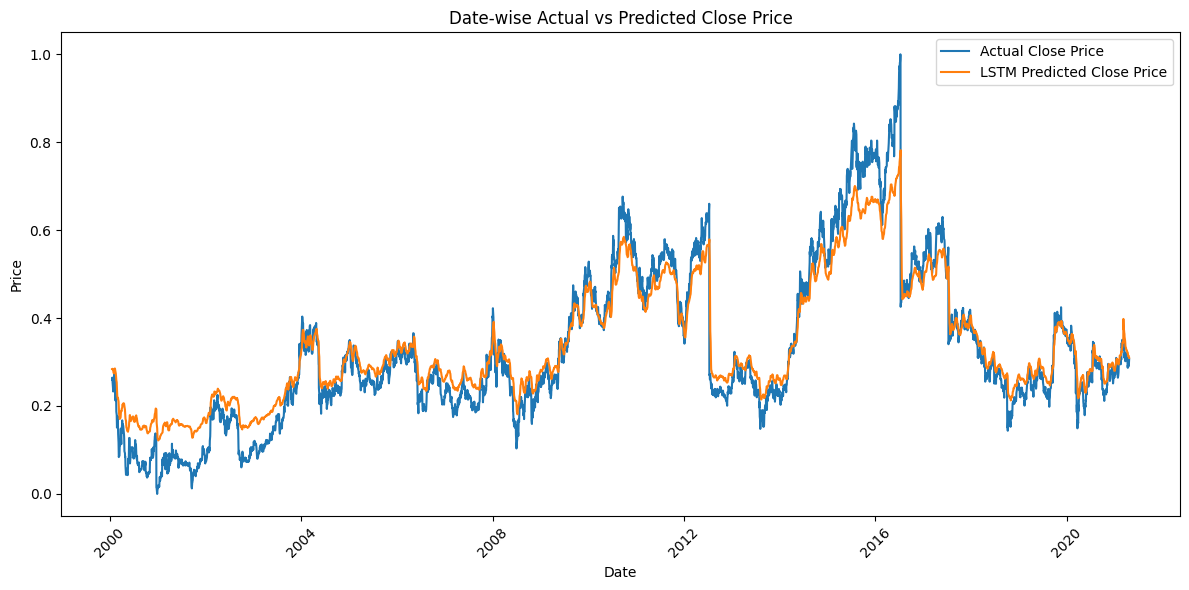

In [35]:
plt.figure(figsize=(12,6))

plt.plot(dates_plot, actual, label="Actual Close Price")
plt.plot(dates_plot, predicted, label="LSTM Predicted Close Price")

plt.title("Date-wise Actual vs Predicted Close Price")
plt.xlabel("Date")
plt.ylabel("Price")
plt.legend()
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

This assignment involved the implementation of an LSTM model for multi-step time series forecasting using NIFTY-50 stock market data.
The data was preprocessed using Min-Max scaling and converted into sequences using a sliding window approach.
The model was trained to predict future stock values based on past trends.
Performance was evaluated using MSE, MAE, and RMSE, and results were visualized using date-wise actual vs predicted plots.